# Machine learning approach 

During this notebook, we are testing different ML algorithms to tackle hypoglycemia prediction problem  

Create our own class to compare different models against several horizons and metrics

In [1]:
import os 
import pandas as pd 
import numpy as np 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.append("..")
from scripts.window_regressor import Window_Regressor_Sequence_to_scalar

In [3]:
class Models_Horizon():
    def __init__(self, cut_point:int, test_size:float , window_size:int, horizon:int, folds:int, models:list, model_names:list, metrics:list):
        self.cut_point = cut_point
        self.test_size = test_size
        self.window_size = window_size
        self.horizon = horizon
        self.folds = folds
        self.models = models
        self.model_names = model_names
        self.metrics = metrics


        self.patients = self.load_patients()
        self.results = None
    
    def load_patients(self):
        data_dir = '../Data/Preprocessed'
        base_paths = os.listdir(data_dir)
        full_paths = [os.path.join(data_dir, p) for p in base_paths]
        patients = {}
        spliter = TimeSeriesSplit(n_splits=self.folds, test_size=288) ## We test using one day
        for i, fp in enumerate(full_paths):
            key = base_paths[i].split('.')[0]
            patients[key] = []
            data = pd.read_csv(fp, sep=';')[:self.cut_point]['glucose']
            for k_fold in spliter.split(data):
                k_train = data[k_fold[0]]
                k_test = data[k_fold[1]]
                proper_ml_train_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_train, window_size=self.window_size, horizon=self.horizon)
                proper_ml_test_k_fold = Window_Regressor_Sequence_to_scalar(time_series_data=k_test, window_size=self.window_size, horizon=self.horizon)
                patients[key].append((proper_ml_train_k_fold.generated_data_set, proper_ml_test_k_fold.generated_data_set))
        return patients
    
    def test_models(self):
        keys = list(self.patients.keys())
        results = []
        for key in keys:
            data_folds = self.patients[key] ## A list of tuples 
            columns = data_folds[0][0].columns ## Just to extract columns
            tensor_results_metrics = np.zeros(shape=(len(self.model_names), len(self.metrics), self.folds)) ## 3 cause, we're measuring MSE,MAE and MAPE

            for k, fold in enumerate(data_folds):
                train_k, test_k = fold[0], fold[1]
                X_train_k, y_train_k = train_k[columns[:-1]], train_k[columns[-1]]
                X_test_k, y_test_k = test_k[columns[:-1]], test_k[columns[-1]]
                for m, model in enumerate(self.models):
                    model = clone(model)
                    model.fit(X_train_k, y_train_k)
                    y_pred_k = model.predict(X_test_k)
                    for z, metric in enumerate(self.metrics):
                        result_metric = metric(y_true=y_test_k, y_pred=y_pred_k)
                        tensor_results_metrics[m][z][k] = result_metric
                        
            mse_all_models = tensor_results_metrics[:, 0, :]
            mae_all_models = tensor_results_metrics[:, 1, :]
            mape_all_models = tensor_results_metrics[:, 2, :]

            results.append(list(np.mean(mse_all_models, axis=1)) + list(np.mean(mae_all_models, axis=1)) + list(np.mean(mape_all_models, axis=1)))

        ### Prepare and return a df 
        metrics = ['mse', 'mae', 'mape']
        col_index = pd.MultiIndex.from_product([metrics, self.model_names], names=['metric', 'model'])
        df_final = pd.DataFrame(
            results,
            index=keys,
            columns=col_index
        )
        self.results = df_final
        return df_final

    def visualize_model_comparison(self, figsize=(15, 7)):
        if self.results is None:
            raise ValueError("No results to visualize. Run 'test_models()' first.")
    

        metrics = ['mse', 'mae', 'mape']
        model_names = self.model_names

        _, axes = plt.subplots(1, 3, figsize=figsize)
        colors = ['steelblue', 'seagreen', 'tomato']

        for ax, metric, color in zip(axes, metrics, colors):

            data_plot = self.results[metric]  

            data_long = data_plot.reset_index().melt(
                id_vars='index',
                var_name='Model',
                value_name=metric.upper()
            )
            data_long['Model'] = pd.Categorical(data_long['Model'], categories=model_names)

    
            sns.boxplot(
                data=data_long,
                x='Model',
                y=metric.upper(),
                ax=ax,
                color=color,
                width=0.6
            )

            ax.set_title(f'{metric.upper()}: Window_size:{self.window_size}, Horizon:{self.horizon}')
            ax.set_xlabel('Modelo')
            ax.set_ylabel(metric.upper())
            ax.tick_params(axis='x', rotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout()
        plt.show()
        
        ## Visualize a summary for each metric
        for m in metrics:
            print(f'{m.upper()}')
            print(self.results[m].describe())
        

## Test it using random forest regressor and gradient boost regressor 

In [4]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler


In [5]:
cut_point = 2290
test_size = 0.2
window_size = 12
horizon = 3
folds = 5
models = [
    RandomForestRegressor(
        n_estimators=100,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          
        min_samples_split=10,
        min_samples_leaf=5,
        subsample=0.8,
        random_state=42
    ),
    XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,          
        min_child_weight=10,  
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ),
    Pipeline(steps=[('scaler', MinMaxScaler(feature_range=(0,1))), ('model', LinearRegression())]),
    Pipeline(steps=[
        ('scaler', MinMaxScaler(feature_range=(0, 1))),
        ('model', RidgeCV(
            alphas=np.logspace(-4, 4, 50),   # ajustable
            cv=None,                         # ← GCV
            store_cv_results=False
        ))
    ]), 
    Pipeline(
    steps=[
        ('scaler', MinMaxScaler(feature_range=(0, 1))),
        ('model', LassoCV(
            alphas=np.linspace(0.01, 1, 50),
            cv=5,
            max_iter=10000
        ))
    ]
    )
]
model_names = ['random_forest', 'gradient_boost', 'xgboost', 'linear_regression', 'ridge_regression', 'lasso_regression']
metrics = [mean_squared_error, mean_absolute_error, mean_absolute_percentage_error]

In [6]:
horizon_3 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=horizon, 
    folds=folds,
    models=models, 
    model_names=model_names, 
    metrics=metrics
)

In [7]:
results = horizon_3.test_models()

In [8]:
results

metric              mse                                               \
model     random_forest gradient_boost     xgboost linear_regression   
HUPA0004P    297.665104     126.079226  136.209190         50.221597   
HUPA0006P    340.486076     205.805668  225.846703         49.198094   
HUPA0007P    531.180155     434.412752  436.400687        415.206268   
HUPA0009P    126.147175     104.525759  102.419768         15.361869   
HUPA0005P    168.691764     127.828462  136.993966         97.554003   
HUPA0011P    434.024234     313.725138  347.936353        134.409388   
HUPA0003P    225.322697     177.737195  177.754264        134.358384   
HUPA0001P    489.946079     406.333562  407.028863        273.949145   
HUPA0010P    271.982271     171.319742  202.289369         58.754991   
HUPA0002P    151.940165     108.903985  120.738385         39.442100   
HUPA0014P    687.452617     486.492226  564.832618         53.737223   
HUPA0015P    233.601084     132.389083  148.619752         41.634783   
HUPA0016P    208.968228     119.564400  135.153832         58.126308   
HUPA0017P    169.089159     110.991352  119.093310         67.950186   
HUPA0018P    241.901792     123.015989  142.149221         56.541053   
HUPA0021P    247.265004     181.208830  190.965420         72.202174   
HUPA0020P    220.662909     113.526780  130.264468         46.867624   
HUPA0024P    192.647759      98.477420  106.274031         50.698110   
HUPA0019P    361.770255     216.337270  232.947302         90.329290   
HUPA0023P    224.100981     161.760198  179.316951         52.517164   
HUPA0022P    141.550938     134.993678  133.252853        122.199965   
HUPA0025P    138.438048     124.761540  124.500103         45.747580   
HUPA0028P    202.810117     156.527619  169.084424         73.436950   
HUPA0026P    213.161164     116.793870  127.126141         66.291810   
HUPA0027P    110.811712      90.452143  101.689147         55.040476   

metric                                                mae                 \
model     ridge_regression lasso_regression random_forest gradient_boost   
HUPA0004P        50.282532        61.748192     13.234845       8.341289   
HUPA0006P        49.232427        56.313671     13.494021      10.078383   
HUPA0007P       439.382948       422.505032     16.481258      13.952897   
HUPA0009P        15.794509        15.791452      7.275922       4.919571   
HUPA0005P        98.742290       100.554358      9.760563       8.275942   
HUPA0011P       135.049544       135.977231     13.824211      11.715935   
HUPA0003P       134.575996       133.626768     11.225298       9.280014   
HUPA0001P       273.200727       268.370608     15.650734      13.204536   
HUPA0010P        62.623279        65.185959     10.346896       6.806202   
HUPA0002P        39.430229        44.518771      9.002783       7.405238   
HUPA0014P        53.710182        57.781539     13.210262       9.926296   
HUPA0015P        41.756211        54.587669     11.016193       8.376362   
HUPA0016P        58.107174        66.118450     10.664240       8.081025   
HUPA0017P        67.837322        71.788302      9.845355       7.646172   
HUPA0018P        56.610001        63.174714     11.888068       7.937860   
HUPA0021P        72.289577        78.169485     11.167789       9.037295   
HUPA0020P        46.986210        56.751048     11.749673       8.100793   
HUPA0024P        50.659157        61.044705     10.487267       7.501543   
HUPA0019P        90.457768        95.787417     13.778757      10.424108   
HUPA0023P        52.551363        57.121311     10.196661       7.988174   
HUPA0022P       123.756662       122.404666      8.147299       8.130873   
HUPA0025P        45.816605        49.038680      8.197224       6.989456   
HUPA0028P        73.461922        77.183115      9.617491       7.982739   
HUPA0026P        66.280563        73.940972     11.278817       7.569952   
HUPA0027P        55.039522        58.897396      7.981755       6.960630   

me

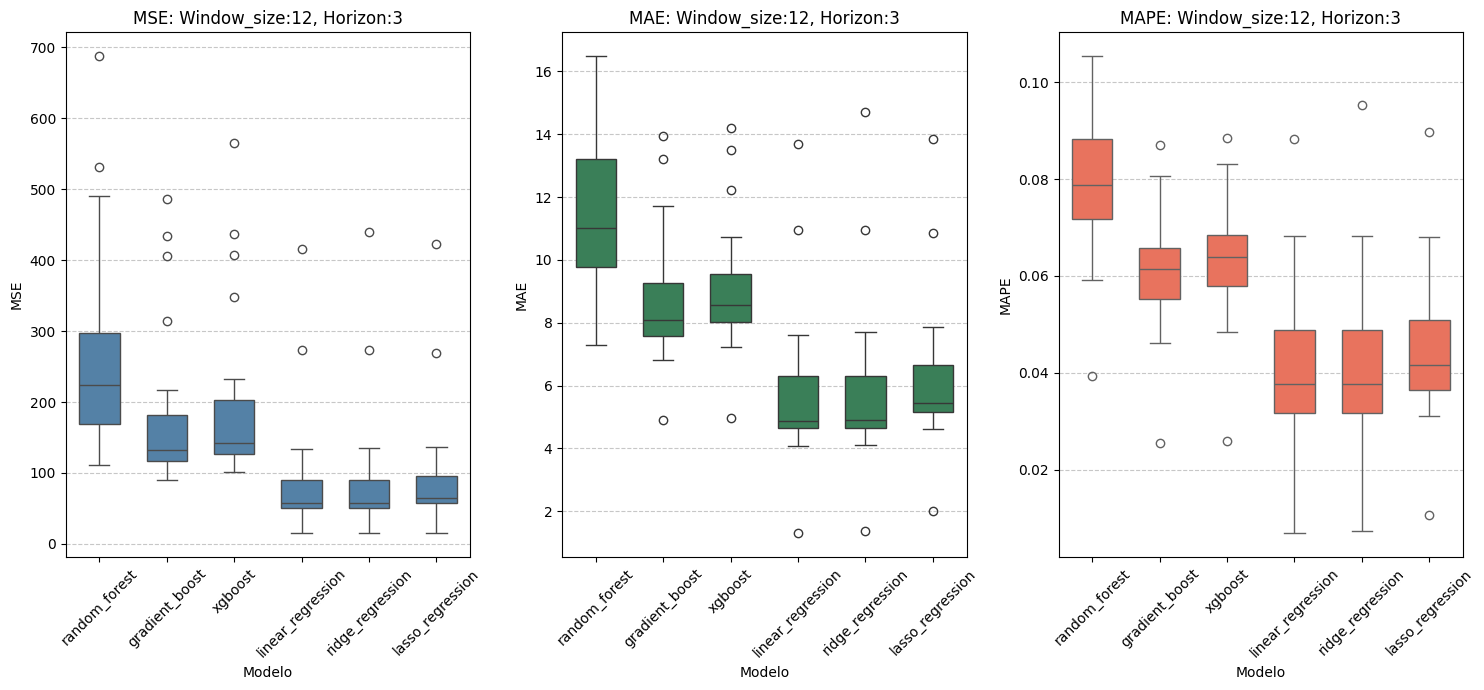

MSE
model  random_forest  gradient_boost     xgboost  linear_regression  \
count      25.000000       25.000000   25.000000          25.000000   
mean      265.264699      181.758555  195.955485          88.871061   
std       140.268950      109.755691  118.392655          84.746722   
min       110.811712       90.452143  101.689147          15.361869   
25%       169.089159      116.793870  127.126141          50.221597   
50%       224.100981      132.389083  142.149221          58.126308   
75%       297.665104      181.208830  202.289369          90.329290   
max       687.452617      486.492226  564.832618         415.206268   

model  ridge_regression  lasso_regression  
count         25.000000         25.000000  
mean          90.145389         93.935260  
std           88.578563         83.534094  
min           15.794509         15.791452  
25%           50.282532         57.121311  
50%           58.107174         65.185959  
75%           90.457768         95.787417  
max 

In [9]:
horizon_3.visualize_model_comparison()

In [10]:
horizon_6 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=6, 
    folds=folds,
    models=models, 
    model_names=model_names, 
    metrics=metrics
)

/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.645e+02, tolerance: 4.218e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.775e+02, tolerance: 3.229e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation

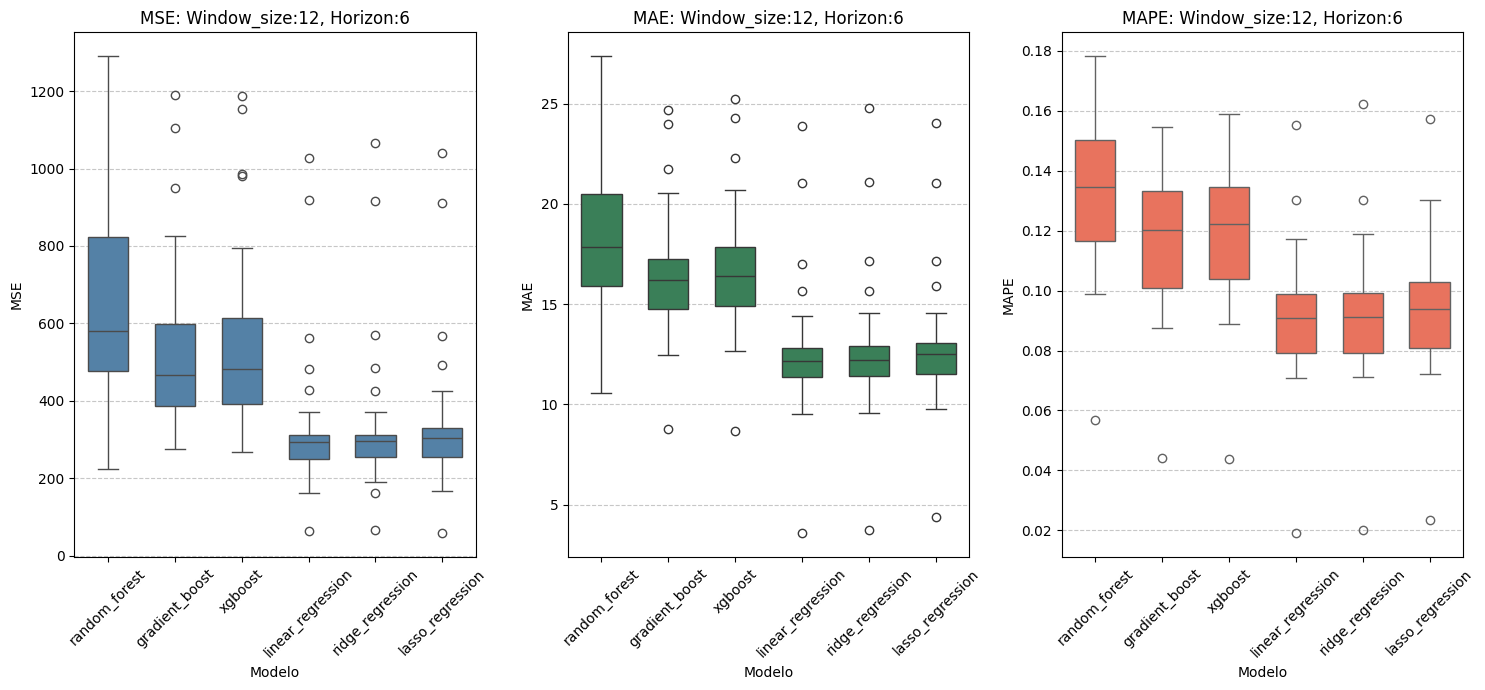

MSE
model  random_forest  gradient_boost      xgboost  linear_regression  \
count      25.000000       25.000000    25.000000          25.000000   
mean      652.939304      549.078828   571.089187         345.177746   
std       297.265701      248.929209   261.625578         213.660547   
min       222.998591      275.137530   267.752299          64.258559   
25%       477.660028      386.184861   392.170678         249.539545   
50%       579.326999      466.292811   482.029957         294.797537   
75%       823.506159      597.630497   614.993764         311.650913   
max      1290.205579     1190.514072  1187.996126        1027.007682   

model  ridge_regression  lasso_regression  
count         25.000000         25.000000  
mean         347.890923        352.338956  
std          218.596803        213.447348  
min           66.243685         58.672290  
25%          255.671378        255.249041  
50%          296.293313        305.251474  
75%          312.348057        330.0780

In [11]:
horizon_6.test_models()
horizon_6.visualize_model_comparison()

In [12]:
horizon_12 = Models_Horizon(
    cut_point=cut_point, 
    test_size=test_size, 
    window_size=window_size, 
    horizon=12, 
    folds=folds,
    models=models, 
    model_names=model_names, 
    metrics=metrics
)

/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.922e+03, tolerance: 4.218e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.991e+02, tolerance: 3.127e+02
  model = cd_fast.enet_coordinate_descent_gram(
/home/arturo27/.local/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation

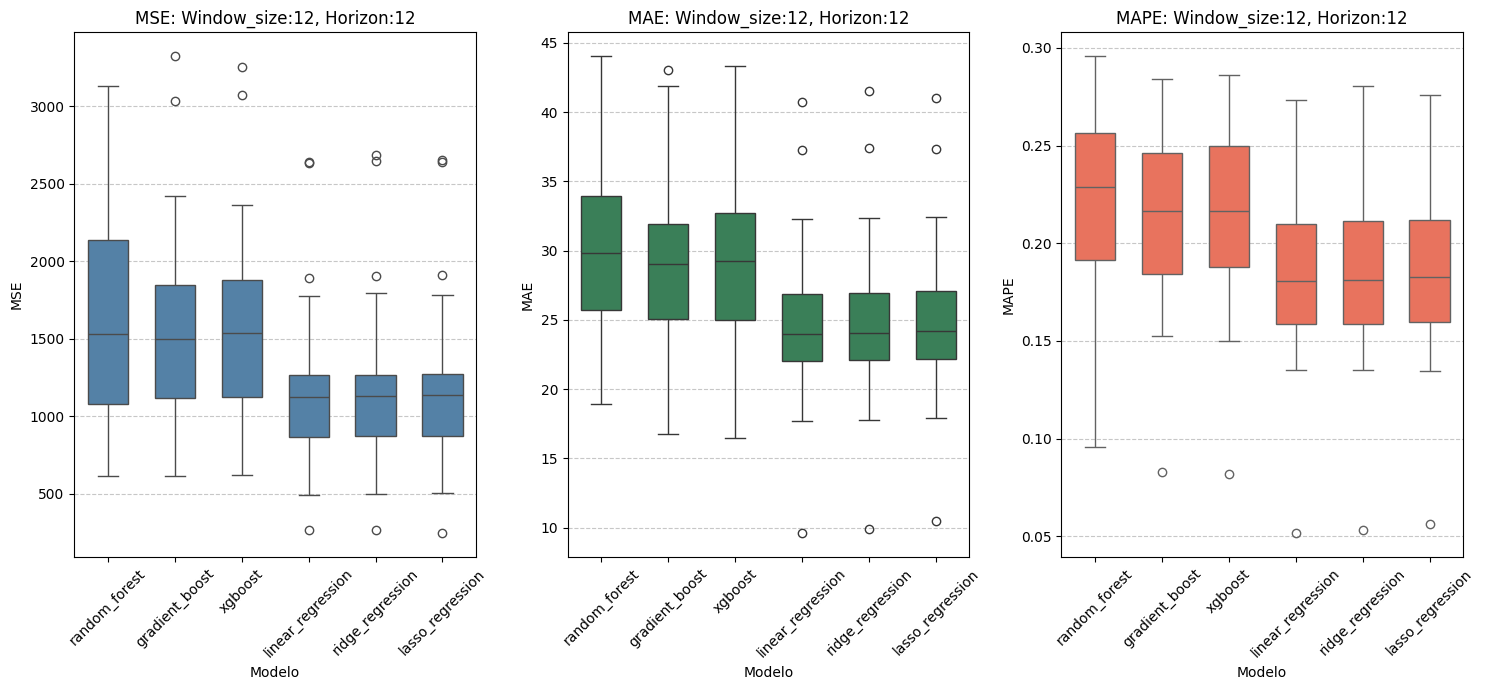

MSE
model  random_forest  gradient_boost      xgboost  linear_regression  \
count      25.000000       25.000000    25.000000          25.000000   
mean     1616.654081     1578.403596  1593.032918        1164.041678   
std       696.445396      676.464496   681.235703         574.271370   
min       615.821768      613.099396   618.548240         265.530049   
25%      1078.211543     1117.061241  1124.042250         868.219523   
50%      1529.808042     1497.850566  1536.047589        1123.346837   
75%      2139.385754     1847.747901  1880.336549        1266.431041   
max      3129.469440     3324.720327  3255.655228        2643.823940   

model  ridge_regression  lasso_regression  
count         25.000000         25.000000  
mean        1171.164665       1172.345500  
std          581.568807        577.991473  
min          269.382613        247.139059  
25%          871.411611        873.433480  
50%         1128.267798       1139.018322  
75%         1269.846181       1275.9347

In [13]:
horizon_12.test_models()
horizon_12.visualize_model_comparison()